# Exerciții Matplotlib (ușor–mediu) – WorldCups

Dataset: `WorldCups - WorldCups.csv`

**Instrucțiuni:** fiecare exercițiu are o întrebare și apoi o celulă de cod cu rezolvarea.


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# setări simple de afișare (opțional)
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (10, 4)

In [18]:
df = pd.read_csv('WorldCups - WorldCups.csv')
df.head()

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,18
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,17
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,18
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,13,22
4,1954,Switzerland,Germany FR,Hungary,Austria,Uruguay,140,16,26


## Exercițiul 1 – `describe()` pentru coloane numerice

Afișează statistici descriptive pentru `GoalsScored`, `QualifiedTeams`, `MatchesPlayed` folosind `describe()`.


In [19]:
df[["GoalsScored", "QualifiedTeams", "MatchesPlayed"]].describe()

,GoalsScored,QualifiedTeams,MatchesPlayed
count,22.000000,22.000000,22.000000
mean,123.636364,22.227273,43.818182
std,34.841882,7.602830,17.632860
min,70.000000,13.000000,17.000000
25%,90.500000,16.000000,32.000000
50%,129.000000,20.000000,45.000000
75%,146.750000,32.000000,64.000000
max,172.000000,32.000000,64.000000


## Exercițiul 2 – linie simplă: `GoalsScored` în funcție de `Year`

Fă un grafic linie (`plt.plot`) cu `Year` pe axa X și `GoalsScored` pe axa Y.
Adaugă titlu și etichete pentru axe.


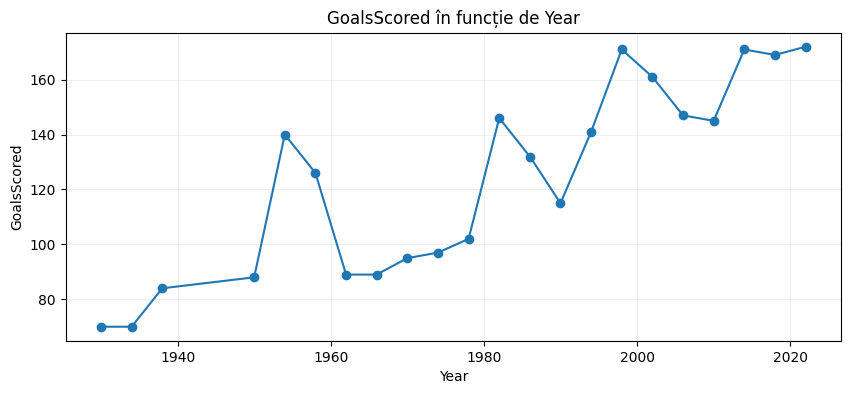

In [20]:
plt.plot(df["Year"], df["GoalsScored"], marker="o")
plt.title("GoalsScored în funcție de Year")
plt.xlabel("Year")
plt.ylabel("GoalsScored")
plt.grid(alpha=0.2)
plt.show()

## Exercițiul 3 – linie de referință: media golurilor

Pe același grafic de la exercițiul 2, trasează o linie orizontală cu media `GoalsScored`.
Hint: `plt.axhline(...)`.


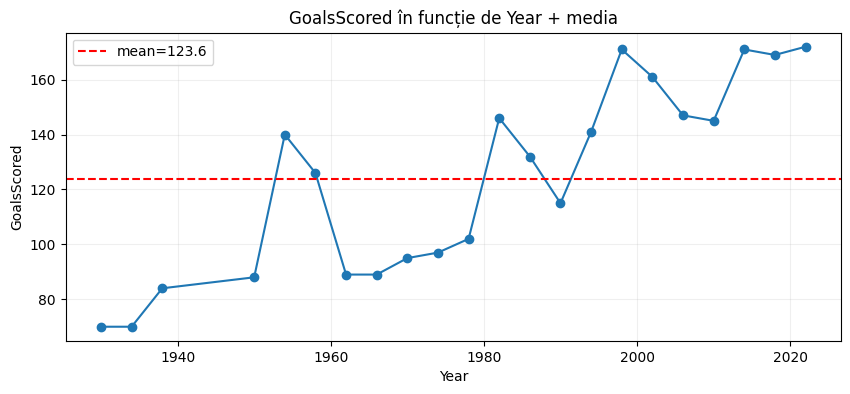

In [21]:
mean_goals = df["GoalsScored"].mean()

plt.plot(df["Year"], df["GoalsScored"], marker="o")
plt.axhline(mean_goals, color="red", linestyle="--", label=f"mean={mean_goals:.1f}")
plt.title("GoalsScored în funcție de Year + media")
plt.xlabel("Year")
plt.ylabel("GoalsScored")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Exercițiul 4 – scatter: `MatchesPlayed` vs `GoalsScored`

Fă un scatter plot (`plt.scatter`) cu:
- X = `MatchesPlayed`
- Y = `GoalsScored`


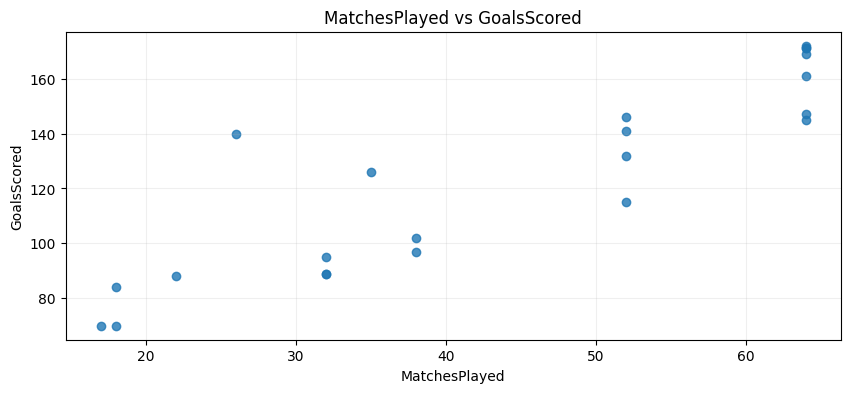

In [22]:
plt.scatter(df["MatchesPlayed"], df["GoalsScored"], alpha=0.8)
plt.title("MatchesPlayed vs GoalsScored")
plt.xlabel("MatchesPlayed")
plt.ylabel("GoalsScored")
plt.grid(alpha=0.2)
plt.show()

## Exercițiul 5 – bar chart: Top 5 ediții după `GoalsScored`

Alege top 5 ani cu cele mai multe goluri și fă un bar chart.
Hint: `df.sort_values(...).head(5)`.


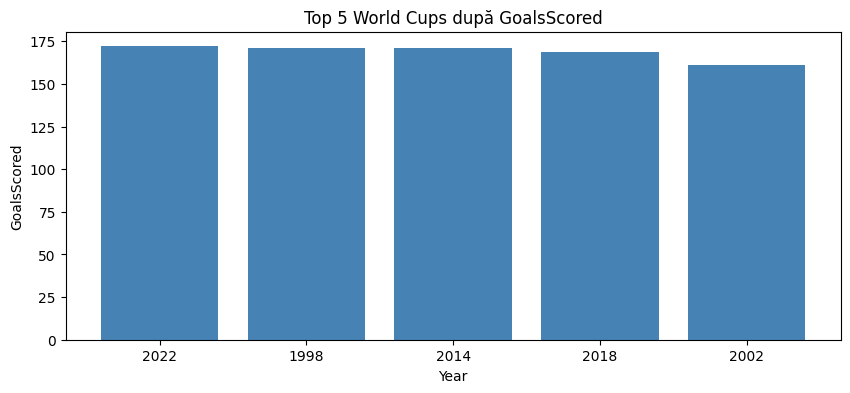

In [23]:
top5 = df.sort_values("GoalsScored", ascending=False).head(5)
plt.bar(top5["Year"].astype(str), top5["GoalsScored"], color="steelblue")
plt.title("Top 5 World Cups după GoalsScored")
plt.xlabel("Year")
plt.ylabel("GoalsScored")
plt.show()

## Exercițiul 6 – mean (media) `GoalsScored`

Calculează media golurilor pe ediție și afișeaz-o.


In [24]:
df["GoalsScored"].mean()

np.float64(123.63636363636364)

## Exercițiul 7 – mediană `GoalsScored`

Calculează mediana golurilor.


In [25]:
df["GoalsScored"].median()

np.float64(129.0)

## Exercițiul 8 – modă (mode) pentru `QualifiedTeams`

Găsește valoarea care apare cel mai des în `QualifiedTeams`.
Hint: `value_counts()`.


In [26]:
df["QualifiedTeams"].value_counts().head(5)

QualifiedTeams
16    8
32    7
24    4
13    2
15    1
Name: count, dtype: int64

## Exercițiul 9 – deviația standard pentru `GoalsScored`

Calculează deviația standard (populație și eșantion) și compară rezultatele.


In [27]:
std_pop = df["GoalsScored"].std(ddof=0)
std_sample = df["GoalsScored"].std(ddof=1)
std_pop, std_sample

(np.float64(34.04081167516621), np.float64(34.84188155017909))

## Exercițiul 10 – histogramă pentru `GoalsScored`

Fă o histogramă cu numărul de goluri.
Hint: `plt.hist(...)`.


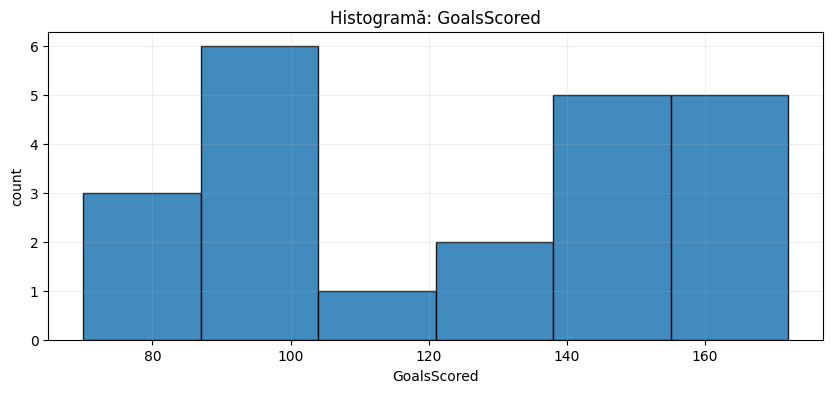

In [28]:
plt.hist(df["GoalsScored"], bins='auto', edgecolor='black', alpha=0.85)
plt.title("Histogramă: GoalsScored")
plt.xlabel("GoalsScored")
plt.ylabel("count")
plt.grid(alpha=0.2)
plt.show()

## Exercițiul 11 – boxplot pentru `GoalsScored`

Fă un boxplot pentru `GoalsScored`.


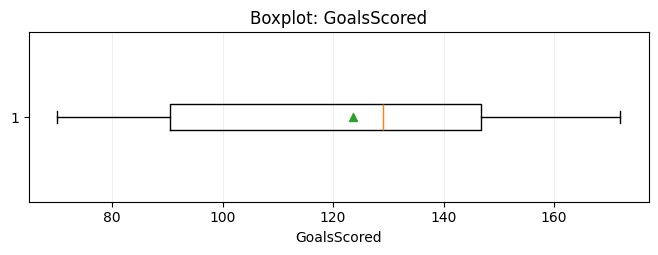

In [29]:
plt.figure(figsize=(8, 2.2))
plt.boxplot(df["GoalsScored"], vert=False, showmeans=True)
plt.title("Boxplot: GoalsScored")
plt.xlabel("GoalsScored")
plt.grid(axis='x', alpha=0.2)
plt.show()

## Exercițiul 12 – quantile/percentile pentru `GoalsScored`

Calculează Q1 (0.25), mediană (0.5) și Q3 (0.75) folosind `quantile`.


In [30]:
df["GoalsScored"].quantile([0.25, 0.5, 0.75])

0.25     90.50
0.50    129.00
0.75    146.75
Name: GoalsScored, dtype: float64

## Exercițiul 13 – outlieri cu regula IQR

Calculează IQR și apoi `lower/upper` pentru `GoalsScored`.
Afișează valorile outlier (dacă există).


In [31]:
q1 = df["GoalsScored"].quantile(0.25)
q3 = df["GoalsScored"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df.loc[(df["GoalsScored"] < lower) | (df["GoalsScored"] > upper), ["Year", "GoalsScored"]]

print(f"IQR = {iqr:.2f}, bounds = [{lower:.2f}, {upper:.2f}]")
outliers if len(outliers) else "(niciun outlier după regula IQR)"

IQR = 56.25, bounds = [6.12, 231.12]


'(niciun outlier după regula IQR)'

## Exercițiul 14 – bar: câte titluri are fiecare `Winner`

Fă un bar chart cu numărul de trofee pentru fiecare țară (Winner).
Hint: `value_counts()`.


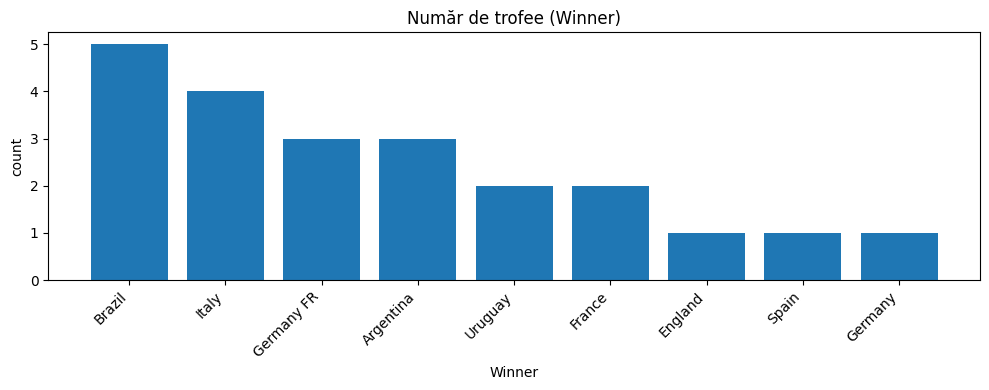

In [32]:
wins = df["Winner"].value_counts()
plt.figure(figsize=(10, 4))
plt.bar(wins.index, wins.values)
plt.title("Număr de trofee (Winner)")
plt.xlabel("Winner")
plt.ylabel("count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Exercițiul 15 – pie chart (simplu): distribuția trofeelor pentru Top 5

Alege top 5 țări după număr de trofee și fă un pie chart.
Hint: `wins.head(5)`.


## Exercițiul 16 – două serii pe același grafic: `GoalsScored` și `MatchesPlayed`

Fă un grafic linie cu `Year` pe axa X și două linii:
- `GoalsScored`
- `MatchesPlayed`

Adaugă legendă.


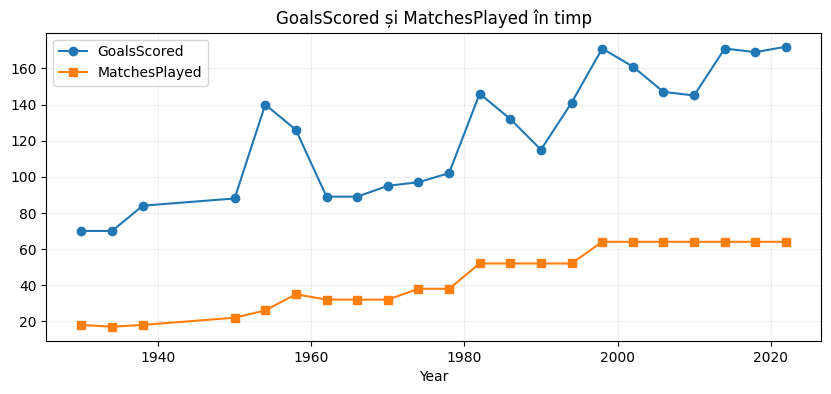

In [33]:
plt.plot(df["Year"], df["GoalsScored"], marker='o', label='GoalsScored')
plt.plot(df["Year"], df["MatchesPlayed"], marker='s', label='MatchesPlayed')
plt.title("GoalsScored și MatchesPlayed în timp")
plt.xlabel("Year")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Exercițiul 17 – `Goals per match` și grafic

Creează o coloană nouă `GoalsPerMatch = GoalsScored / MatchesPlayed`.
Apoi fă un line plot cu `Year` vs `GoalsPerMatch`.


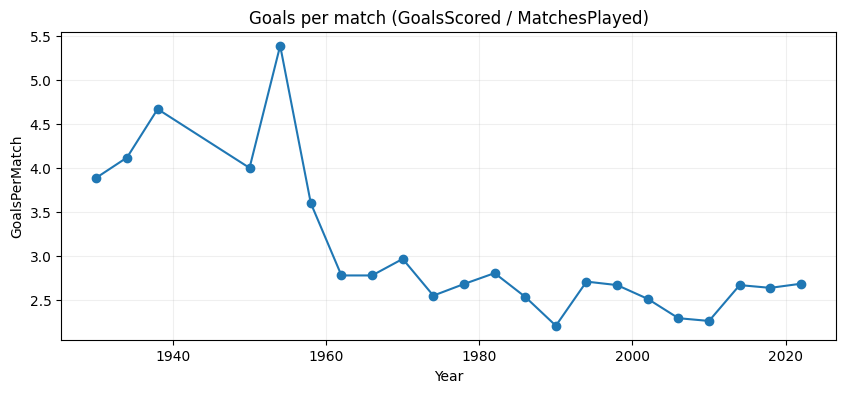

In [34]:
df["GoalsPerMatch"] = df["GoalsScored"] / df["MatchesPlayed"]

plt.plot(df["Year"], df["GoalsPerMatch"], marker='o')
plt.title("Goals per match (GoalsScored / MatchesPlayed)")
plt.xlabel("Year")
plt.ylabel("GoalsPerMatch")
plt.grid(alpha=0.2)
plt.show()

## Exercițiul 18 – subplots: histogramă pentru `GoalsScored` și `MatchesPlayed`

Fă o figură cu 2 subplot‑uri alăturate (1x2):
- stânga: histogramă `GoalsScored`
- dreapta: histogramă `MatchesPlayed`


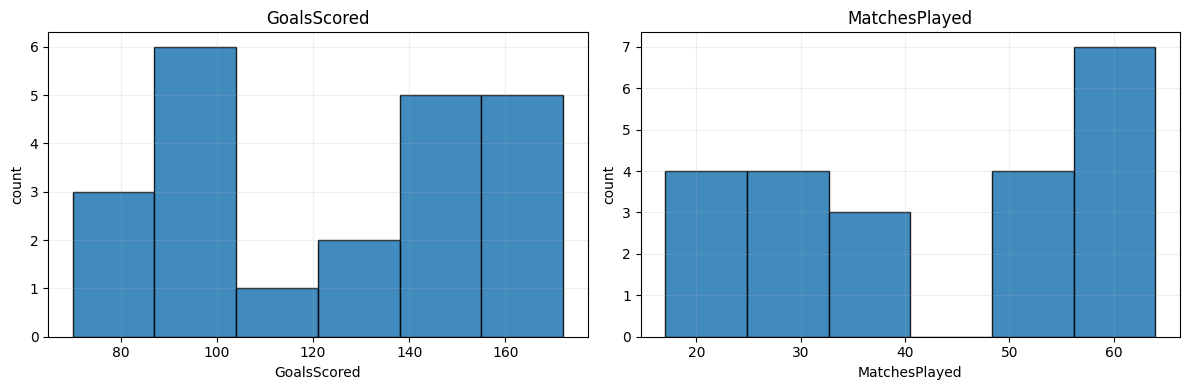

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["GoalsScored"], bins='auto', edgecolor='black', alpha=0.85)
axes[0].set_title("GoalsScored")
axes[0].set_xlabel("GoalsScored")
axes[0].set_ylabel("count")
axes[0].grid(alpha=0.2)

axes[1].hist(df["MatchesPlayed"], bins='auto', edgecolor='black', alpha=0.85)
axes[1].set_title("MatchesPlayed")
axes[1].set_xlabel("MatchesPlayed")
axes[1].set_ylabel("count")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Exercițiul 19 – culori în scatter: `GoalsScored` colorat după `QualifiedTeams`

Fă un scatter plot cu:
- X = `MatchesPlayed`
- Y = `GoalsScored`
- culoarea punctelor = `QualifiedTeams` (folosește argumentul `c=`).


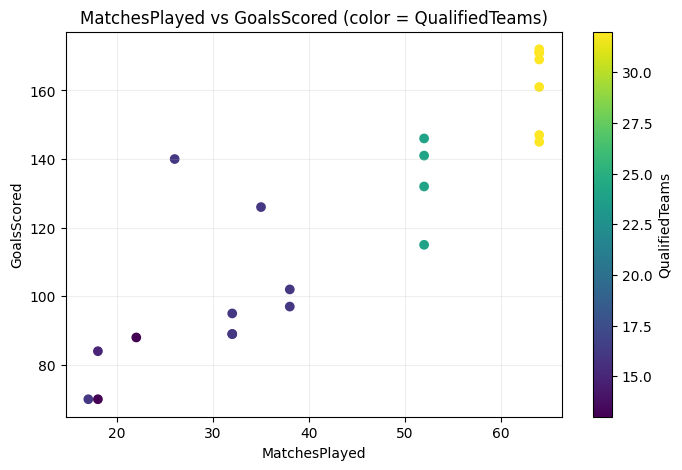

In [36]:
plt.figure(figsize=(8, 5))
sc = plt.scatter(df["MatchesPlayed"], df["GoalsScored"], c=df["QualifiedTeams"], cmap='viridis')
plt.title("MatchesPlayed vs GoalsScored (color = QualifiedTeams)")
plt.xlabel("MatchesPlayed")
plt.ylabel("GoalsScored")
plt.colorbar(sc, label='QualifiedTeams')
plt.grid(alpha=0.2)
plt.show()

## Exercițiul 20 – etichete pe grafic: marchează anul cu maximul de `GoalsScored`

Găsește anul cu cele mai multe goluri și marchează-l pe grafic (scatter + `plt.annotate`).


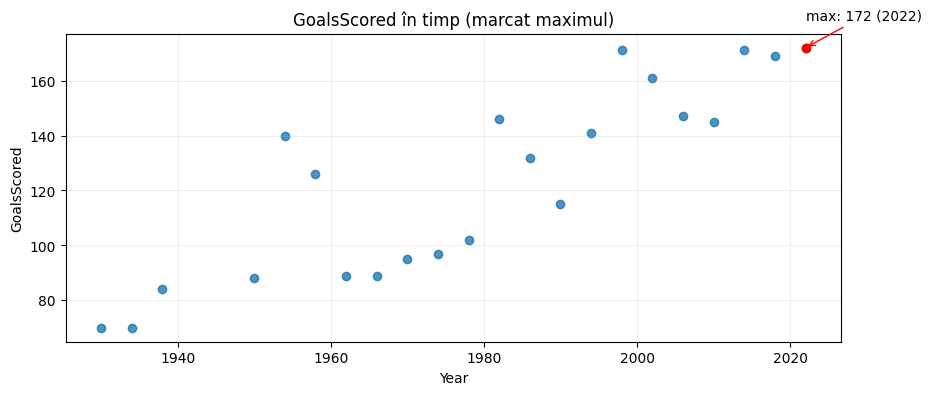

In [37]:
imax = df["GoalsScored"].idxmax()
year_max = int(df.loc[imax, "Year"])
goals_max = int(df.loc[imax, "GoalsScored"])

plt.scatter(df["Year"], df["GoalsScored"], alpha=0.8)
plt.scatter([year_max], [goals_max], color='red')
plt.annotate(f"max: {goals_max} ({year_max})", xy=(year_max, goals_max), xytext=(year_max, goals_max + 10),
             arrowprops=dict(arrowstyle='->', color='red'))
plt.title("GoalsScored în timp (marcat maximul)")
plt.xlabel("Year")
plt.ylabel("GoalsScored")
plt.grid(alpha=0.2)
plt.show()